In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import umap
from sklearn.preprocessing import StandardScaler

/home/alexandre/miniconda3/envs/time_series02/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
prot_name = "1A0H_D"

full_embeddings = np.load(f"output/embeddings_{prot_name}.npy")
ground_truth = np.load(f'output/ground_truth_{prot_name}.npy')
scores = np.load(f"output/score_values_{prot_name}.npy")

rotated_embeddings = np.load(f"output/rotated_embeddings_{prot_name}.npy")
rotated_scores = np.load(f"output/rotated_score_values_{prot_name}.npy")

In [20]:
pred_ref = scores > 0.5
pred_rotated = rotated_scores > 0.5

print("diff ratio =", len(np.argwhere(pred_ref != pred_rotated)) / len(pred_ref))

diff ratio = 0.06621503496503496


In [ ]:
for i in range(20):
    rotated_embeddings = np.load(f"output/rotated{i}_embeddings_{prot_name}.npy")
    rotated_scores = np.load(f"output/rotated{i}_score_values_{prot_name}.npy")
    
    print("Mean embedding L2 distance to ref embedding:", np.linalg.norm((rotated_embeddings - full_embeddings), axis=1).mean())
    p'in()

Mean embedding L2 distance to ref embedding: 1.0492388
Mean embedding L2 distance to ref embedding: 0.46887046
Mean embedding L2 distance to ref embedding: 1.1313467
Mean embedding L2 distance to ref embedding: 1.2095321
Mean embedding L2 distance to ref embedding: 1.0612662
Mean embedding L2 distance to ref embedding: 0.8117396
Mean embedding L2 distance to ref embedding: 1.1964
Mean embedding L2 distance to ref embedding: 1.0388563
Mean embedding L2 distance to ref embedding: 0.8363113
Mean embedding L2 distance to ref embedding: 1.0297077
Mean embedding L2 distance to ref embedding: 1.1834183
Mean embedding L2 distance to ref embedding: 0.8398871
Mean embedding L2 distance to ref embedding: 1.2250342
Mean embedding L2 distance to ref embedding: 0.25372618
Mean embedding L2 distance to ref embedding: 1.1463677
Mean embedding L2 distance to ref embedding: 0.9306279
Mean embedding L2 distance to ref embedding: 1.0987707
Mean embedding L2 distance to ref embedding: 0.8720055
Mean embedd

In [14]:
rotated_scores

array([0.08258647, 0.25122073, 0.83508253, ..., 0.40290928, 0.35271826,
       0.71514827], shape=(4576,), dtype=float32)

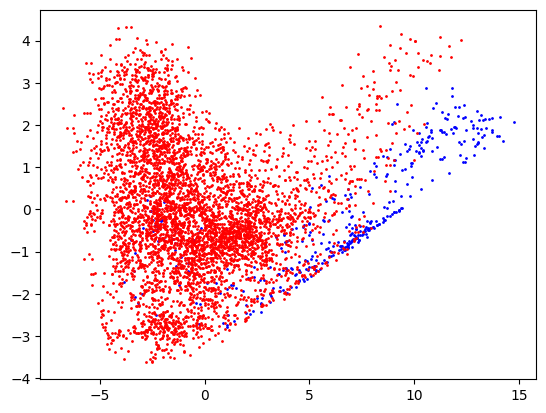

/home/alexandre/miniconda3/envs/time_series02/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


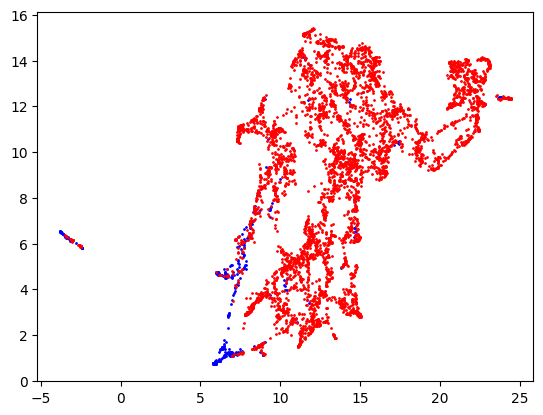

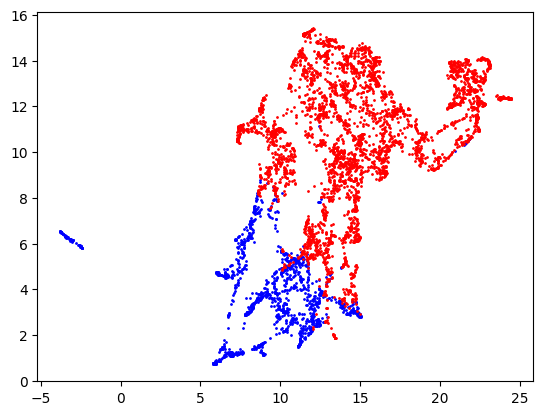

In [ ]:
prot_name = "3AXJ_A"


full_embeddings = np.load(f"output/embeddings_{prot_name}.npy")
ground_truth = np.load(f'output/ground_truth_{prot_name}.npy')
scores = np.load(f"output/score_values_{prot_name}.npy")

# noisy_full_embeddings = np.load(f"output/noisy_embeddings_{prot_name}.npy")
# noisy_ground_truth = np.load(f'output/noisy_ground_truth_{prot_name}.npy')
# noisy_scores = np.load(f'output/noisy_score_values_{prot_name}.npy')

model_ref = PCA(n_components=2)

pca_emb = model_ref.fit_transform(full_embeddings)

plt.scatter(pca_emb[np.argwhere(ground_truth > 0.5), 0], pca_emb[np.argwhere(ground_truth > 0.5), 1], s=1, c='b')
plt.scatter(pca_emb[np.argwhere(ground_truth < 0.5), 0], pca_emb[np.argwhere(ground_truth < 0.5), 1], s=1, c='r')
# plt.scatter(pca_emb[np.argwhere((scores > 0.5) == ground_truth), 0], pca_emb[np.argwhere((scores > 0.5) == ground_truth), 1], s=1, c='g')
plt.show()
plt.clf()

# noisy_model = PCA(n_components=2)
# noisy_emb = noisy_model.fit_transform(noisy_full_embeddings)

# plt.scatter(-noisy_emb[np.argwhere(noisy_ground_truth > 0.5), 0], noisy_emb[np.argwhere(noisy_ground_truth > 0.5), 1], s=1, c='b')
# plt.scatter(-noisy_emb[np.argwhere(noisy_ground_truth < 0.5), 0], noisy_emb[np.argwhere(noisy_ground_truth < 0.5), 1], s=1, c='r')
# # plt.scatter(-noisy_emb[np.argwhere((noisy_scores > 0.5) == noisy_ground_truth), 0], noisy_emb[np.argwhere((noisy_scores > 0.5) == noisy_ground_truth), 1], s=1, c='g')
# plt.show()

# print(len(noisy_ground_truth), len(ground_truth))



scaler = StandardScaler()
scaled_embeddings = scaler.fit_transform(full_embeddings)

reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(scaled_embeddings)

plt.clf()
plt.scatter(embedding_2d[np.argwhere(ground_truth > 0.5), 0], embedding_2d[np.argwhere(ground_truth > 0.5), 1], s=1, c='b')
plt.scatter(embedding_2d[np.argwhere(ground_truth < 0.5), 0], embedding_2d[np.argwhere(ground_truth < 0.5), 1], s=1, c='r')
plt.show()

plt.clf()
plt.scatter(embedding_2d[np.argwhere(scores > 0.5), 0], embedding_2d[np.argwhere(scores > 0.5), 1], s=1, c='b')
plt.scatter(embedding_2d[np.argwhere(scores < 0.5), 0], embedding_2d[np.argwhere(scores < 0.5), 1], s=1, c='r')
plt.show()



In [ ]:
print(roc_auc_score(ground_truth, scores))

print(f1_score(ground_truth, scores >= 0.5))
accuracy_score(ground_truth, (scores >= 0.5))

print(np.unique(ground_truth, return_counts=True))

0.9322247313226374
0.6015037593984962
(array([0., 1.]), array([1967,  172]))


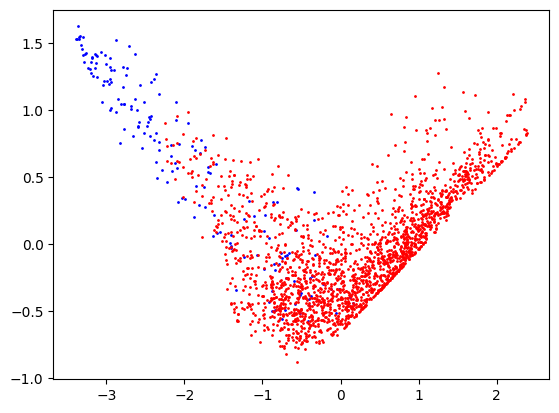

In [ ]:
model = PCA(n_components=2)
pred = model.fit_transform(fc2_embeddings)

positive_sites = np.argwhere(ground_truth > 0.5)
negative_sites = np.argwhere(ground_truth <= 0.5)

plt.scatter(pred[positive_sites, 0], pred[positive_sites, 1], c='b', s=1)
plt.scatter(pred[negative_sites, 0], pred[negative_sites, 1], c='r', s=1)

noise std = 0.01

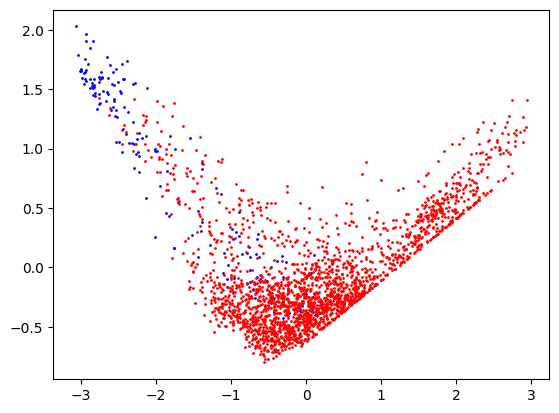

In [ ]:
model = PCA(n_components=2)
pred = model.fit_transform(fc2_embeddings)

positive_sites = np.argwhere(ground_truth > 0.5)
negative_sites = np.argwhere(ground_truth <= 0.5)

plt.scatter(pred[positive_sites, 0], pred[positive_sites, 1], c='b', s=1)
plt.scatter(pred[negative_sites, 0], pred[negative_sites, 1], c='r', s=1)

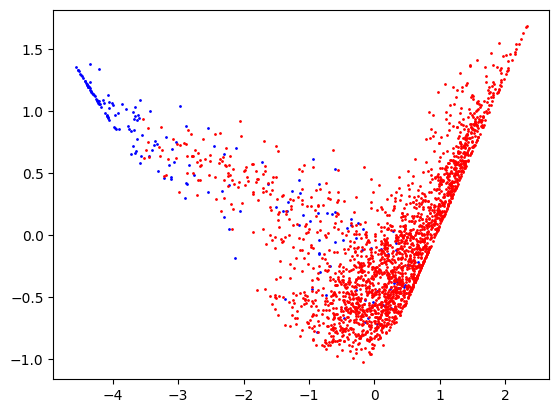

In [ ]:
model = PCA(n_components=2)
pred = model.fit_transform(fc2_embeddings)

positive_sites = np.argwhere(ground_truth > 0.5)
negative_sites = np.argwhere(ground_truth <= 0.5)

plt.scatter(pred[positive_sites, 0], pred[positive_sites, 1], c='b', s=1)
plt.scatter(pred[negative_sites, 0], pred[negative_sites, 1], c='r', s=1)

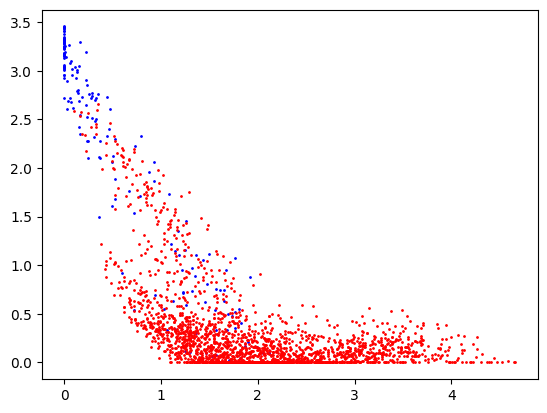

In [ ]:
plt.scatter(fc2_embeddings[positive_sites, 1], fc2_embeddings[positive_sites, 2], s=1, c="b")
plt.scatter(fc2_embeddings[negative_sites, 1], fc2_embeddings[negative_sites, 2], s=1, c="r")


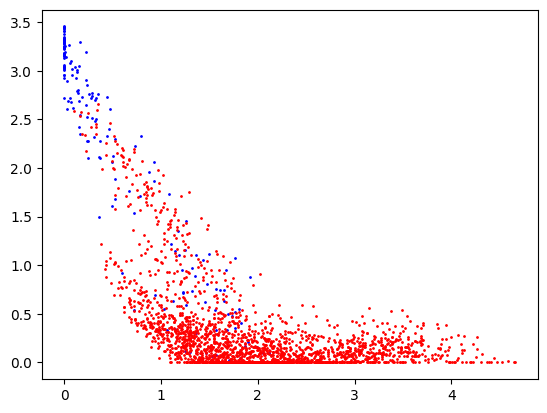

In [ ]:
plt.scatter(fc2_embeddings[positive_sites, 1], fc2_embeddings[positive_sites, 2], s=1, c="b")
plt.scatter(fc2_embeddings[negative_sites, 1], fc2_embeddings[negative_sites, 2], s=1, c="r")



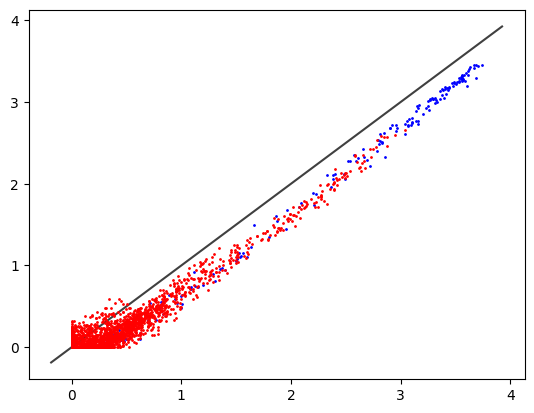

In [ ]:
fig, ax = plt.subplots()

plt.scatter(fc2_embeddings[positive_sites, 0], fc2_embeddings[positive_sites, 2], s=1, c="b")
plt.scatter(fc2_embeddings[negative_sites, 0], fc2_embeddings[negative_sites, 2], s=1, c="r")

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
plt.plot(lims, lims, 'k-', alpha=0.75, zorder=0)

<StemContainer object of 3 artists>

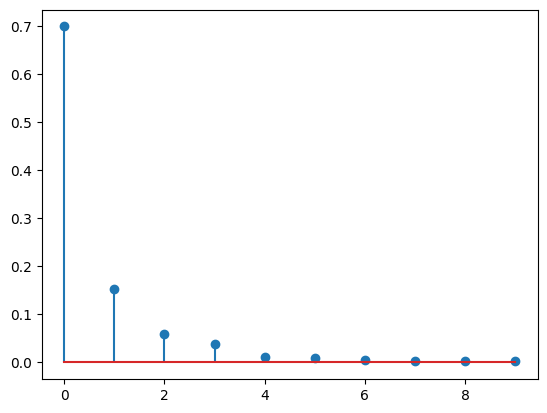

In [ ]:
model = PCA(n_components=10)
pred = model.fit_transform(full_embeddings)
plt.stem(model.explained_variance_ratio_)

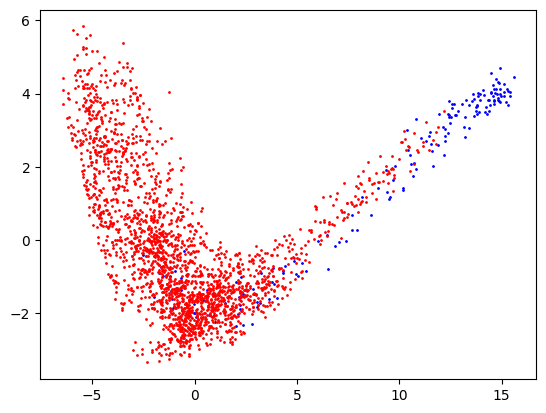

In [ ]:
plt.scatter(pred[positive_sites, 0], pred[positive_sites, 1], c='b', s=1)
plt.scatter(pred[negative_sites, 0], pred[negative_sites, 1], c='r', s=1)

[14 22 24 27 21 17 18 39 59 41 37  2  5  6 33 31 19 16 13 15 30 28 56  7
  8 11 34 20 55 25 32 48 10 52  0  3 43 53 57 12 54 35  1 50  4 58 49 26
 23 29 44 51 38 47 36 40 45 42 46  9]


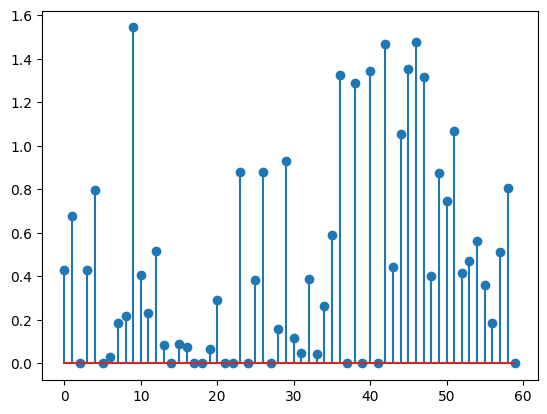

In [ ]:
plt.stem(np.std(full_embeddings, axis=0))
print(np.std(full_embeddings, axis=0).argsort())

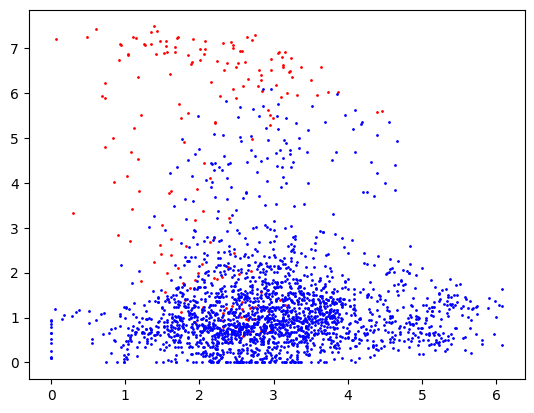

In [ ]:
plt.scatter(full_embeddings[positive_sites, 51], full_embeddings[positive_sites, 46], c='r', s=1)
plt.scatter(full_embeddings[negative_sites, 51], full_embeddings[negative_sites, 46], c='b', s=1)

In [ ]:
tnse_model = TSNE(n_components=2)

tsne_embeddings = tnse_model.fit_transform(full_embeddings)

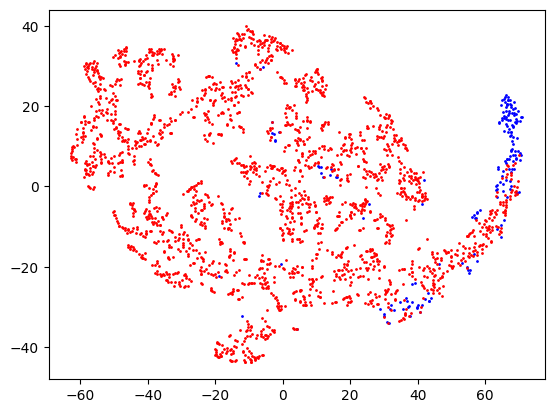

In [ ]:
plt.scatter(tsne_embeddings[positive_sites, 0], tsne_embeddings[positive_sites,1], s=1, c='b')
plt.scatter(tsne_embeddings[negative_sites, 0], tsne_embeddings[negative_sites,1], s=1, c='r')

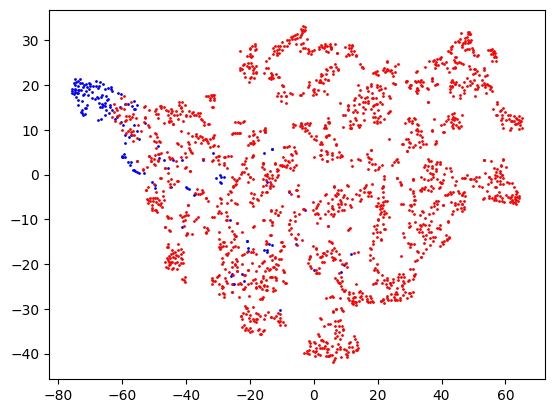

In [ ]:
tnse_model = TSNE(n_components=2)

tsne_embeddings = tnse_model.fit_transform(full_embeddings)

plt.scatter(tsne_embeddings[positive_sites, 0], tsne_embeddings[positive_sites,1], s=1, c='b')
plt.scatter(tsne_embeddings[negative_sites, 0], tsne_embeddings[negative_sites,1], s=1, c='r')